In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'  # MPS fallback for ops not yet implemented on MPS (e.g. linalg_cholesky)

# 00 — Regression Check vs Camera-Ready

Loads a camera-ready pickle from `ICML_2025_Workshop_Submission_Artifacts/pickles/`, extracts its actor state, and replays it through the cleaned pipeline. The cleaned `Actor` class should accept the legacy state dict, and applying the actor to a fresh latent batch should produce a mean reward consistent with the camera-ready run.

This is the **semantic-equivalence check**: it verifies the refactor did not change network architecture, hyperparameters, or evaluation protocol in any way that breaks reproducibility.

If the cleaned pipeline ever evolves (e.g., multiprocessing decode, different reward weight defaults), this notebook flags it.

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import torch

from lisardd.agents.networks import Actor, ActorReinforce
from lisardd.decoding.safe_decode import safe_decode_batch
from lisardd.generators.hiervae_wrapper import HierVAEGenerator
from lisardd.io import load_legacy_pickle
from lisardd.rewards import reward_binding_affinity
from lisardd.scoring.mgraphdta_wrapper import MGraphDTAScorer
from lisardd.targets import get_sequence

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


## Configuration

Point at one camera-ready pickle. The default below targets the JNK3 binding-affinity-only PPO run; change `pickle_name` to test other configurations from the 12-run matrix.

In [3]:
pickle_name = "ppo_binding_jkn3_normalize.pkl"  # note typo preserved from camera-ready filename
target_name = "jnk3"
latent_dim = 32
hidden_dim = 256
n_samples = 100
seed = 42

pickle_path = repo_root / "ICML_2025_Workshop_Submission_Artifacts" / "pickles" / pickle_name
print("pickle exists:", pickle_path.exists())
print("pickle path:", pickle_path)

pickle exists: True
pickle path: /Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/ICML_2025_Workshop_Submission_Artifacts/pickles/ppo_binding_jkn3_normalize.pkl


In [4]:
data = load_legacy_pickle(pickle_path)
print("keys:", list(data.keys()))
print("hyperparameters:", data.get("hyperparameters"))

keys: ['actor_state_dict', 'critic_state_dict', 'avg_obj_scores_ppo', 'loss_actor_list_ppo', 'loss_critic_list_ppo', 'sampled_smiles', 'sampled_rewards', 'random_smiles', 'random_rewards', 'hyperparameters', 'best_latent_vectors', 'best_rewards', 'best_smiles']
hyperparameters: {'latent_dim': 32, 'hidden_dim': 256, 'batch_size': 64, 'clip_eps': 0.2, 'n_epochs': 100, 't_steps': 1, 'gamma': 1.0, 'ppo_epochs': 10, 'penalty_value': -1, 'normalize': False, 'greedy': True, 'reward': 'binding_affinity', 'protein_name': 'jnk3', 'top_n_saved': 100, 'train_date': '2025-06-29T15:07:34.461819'}


## Load actor from pickle into the cleaned `Actor` class

If the architecture matches, `load_state_dict` should succeed without missing/unexpected keys.

In [5]:
actor = Actor(latent_dim, hidden_dim).to(device)
incompat = actor.load_state_dict(data["actor_state_dict"], strict=True)
print("missing keys:", incompat.missing_keys)
print("unexpected keys:", incompat.unexpected_keys)
actor.eval()

missing keys: []
unexpected keys: []


Actor(
  (fc1): Linear(in_features=96, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (actor_head): Linear(in_features=256, out_features=96, bias=True)
)

## Apply actor to a fresh latent batch and score with MGraphDTA

With a fixed seed, this should produce a mean reward in a similar range to the camera-ready averages stored in `data['avg_obj_scores_ppo']`.

In [6]:
torch.manual_seed(seed)

generator = HierVAEGenerator(
    vocab_path=repo_root / "data" / "chembl" / "recovered_vocab_2000.txt",
    ckpt_path=repo_root / "vae_model" / "vae_model.ckpt",
    device=device,
)

scorer = MGraphDTAScorer(
    target_protein=get_sequence(target_name),
    ckpt_path=repo_root / "score_model_weights" / "best_scoring_model.pt",
    device=device,
)
reward_fn = reward_binding_affinity(scorer)

/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/.pixi/envs/default/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/lisardd/generators/hiervae_wrapper.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

In [7]:
with torch.no_grad():
    z_base = torch.randn(n_samples, 3 * latent_dim, device=device)
    mu, std = actor(z_base)
    z_perturbed = torch.distributions.MultivariateNormal(mu, torch.diag_embed(std), validate_args=False).sample()
    z_chunks = torch.chunk(z_perturbed, 3, dim=1)
    smiles, valid = safe_decode_batch(generator.decoder, z_chunks, greedy=True)

valid_mask = torch.tensor(valid, device=device, dtype=torch.bool)
valid_smiles = [s for s, v in zip(smiles, valid) if v]

rewards = torch.zeros(n_samples, device=device)
rewards[~valid_mask] = -1
rewards[valid_mask] = reward_fn(valid_smiles)

print(f"Valid SMILES: {len(valid_smiles)}/{n_samples}")
print(f"Mean reward (replay): {rewards.mean().item():.4f}")

/Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/My Drive/LISARDD_Workshop_Submission/LISARDD/.pixi/envs/default/lib/python3.10/site-packages/torch/distributions/multivariate_normal.py:185: UserWarning: The operator 'aten::linalg_cholesky_ex.L' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/aten/src/ATen/mps/MPSFallback.mm:13.)
  self._unbroadcasted_scale_tril = torch.linalg.cholesky(covariance_matrix)


Valid SMILES: 100/100
Mean reward (replay): 5.8800


In [8]:
import numpy as np

last10 = data["avg_obj_scores_ppo"][-10:]
print(f"Camera-ready avg over last 10 epochs: {np.mean(last10):.4f}")
print(f"Replay mean reward: {rewards.mean().item():.4f}")
print("NOTE: replay uses raw pKd; camera-ready avg is post-normalization, so values are NOT directly comparable.")
print("What to check: replay reward should be in a plausible pKd range (e.g., 5-12) for a trained policy.")

Camera-ready avg over last 10 epochs: 5.9111
Replay mean reward: 5.8800
NOTE: replay uses raw pKd; camera-ready avg is post-normalization, so values are NOT directly comparable.
What to check: replay reward should be in a plausible pKd range (e.g., 5-12) for a trained policy.


## Visualize the policy's preferred molecules

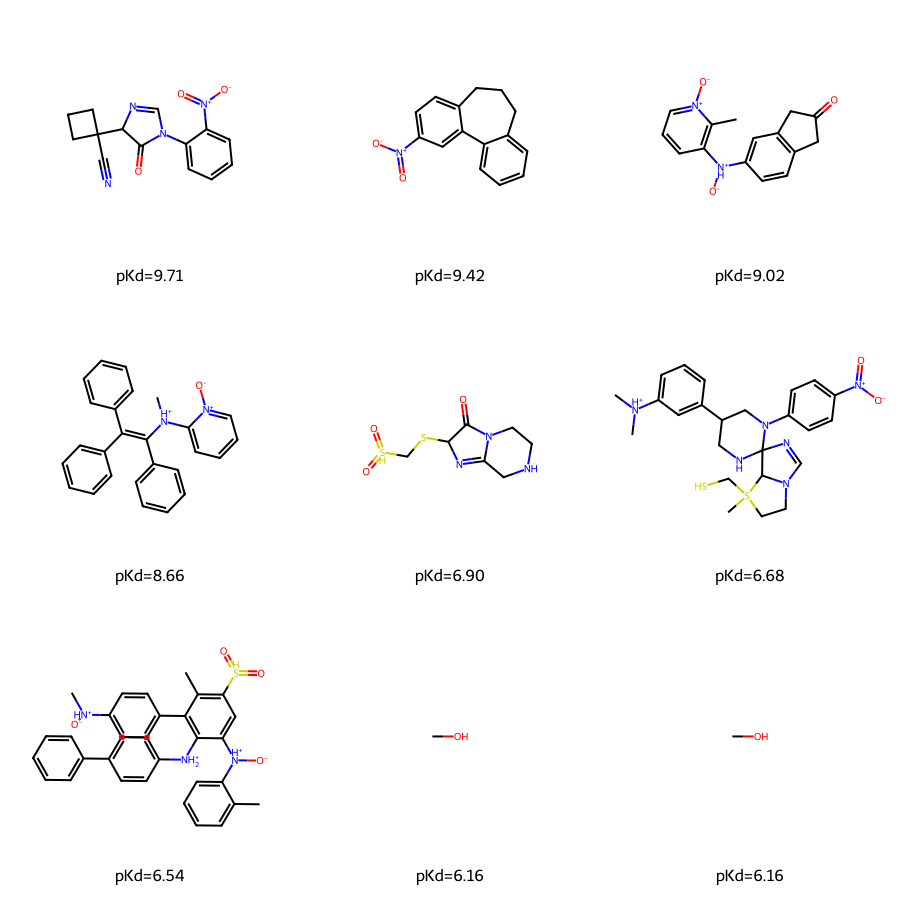

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw

sorted_idx = torch.argsort(rewards, descending=True).tolist()
top_smiles = [smiles[i] for i in sorted_idx[:9] if smiles[i] is not None]
mols = [Chem.MolFromSmiles(s) for s in top_smiles]
legends = [f"pKd={rewards[i].item():.2f}" for i in sorted_idx[:9] if smiles[i] is not None]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300), legends=legends)